# Coletando metadados de trabalhos acadêmicos com LLMs

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import hamming_loss

import datausage as du

Primeiro, vamos inicializar o sistema que será fixo para todas as classificações. Isso inclui o modelo utilizado e o template do prompt.

In [3]:
# Set OpenAI client and config:
key_path = '/home/hxavier/ceweb/config/keys/openai-api-key_ceweb_2025-11-14.txt'
prompt_path = 'prompts/metadata_llm-template_v03.md'
detector = du.PublicDataUsageDetector('gpt-5', key_path, prompt_path, '', '', project=None)

## Teste V02

**Sugestões de aprimoramentos futuros**

* Colocar resposta default para casos borderline na cobertura geográfica: se em dúvida entre mundial e não se aplica, utilizar mundial. Se em dúvida entre uma cobertura geográfica mais ampla ou mais detalhada, usar a mais ampla.
* Aprimorar o prompt com o ChatGPT.

In [4]:
# Colocando batch para rodar:
data_file = '../dados/dspaces/testing/metadata-llm-collect_test-sample_v03.csv'
batch_obj = detector.run_classification(data_file)

In [8]:
# Verificando status da batch:
batch_status = detector.batch_status()

BATCH INFORMATION

[GENERAL]
------------------------------------------------------------
Batch ID              : batch_69c6fae85f88819084b37f32cab51198
Description           : PROMPT: metadata_llm-template_v03 / DATA: metadata-llm-collect_test-sample_v03
Model                 : gpt-5-2025-08-07
Status                : completed

[TIMESTAMPS]
------------------------------------------------------------
Created at            : 2026-03-27 18:47:20
Completed at          : 2026-03-27 18:51:33

[FILES]
------------------------------------------------------------
Input file            : file-D7sCLWUEHqaSBYLCFPoUco
Output file           : file-UFeSWY3YSfQCgG5uUw16D8

[INSTANCES]
------------------------------------------------------------
Total                 : 131
Completed             : 131
Failed                : 0

[TOKENS]
------------------------------------------------------------
Input tokens          : 165017
Cached input tokens   : 0
Output tokens         : 111691
Reasoning tokens 

In [9]:
# Download batch results:
detector.download_results()

Results from batch batch_69c6fae85f88819084b37f32cab51198 saved to ../dados/dspaces/testing/metadata-llm-collect_test-sample_v03_gpt-out.jsonl.


In [10]:
gptin  = '../dados/dspaces/testing/metadata-llm-collect_test-sample_v03_gpt-in.jsonl'
gptout = '../dados/dspaces/testing/metadata-llm-collect_test-sample_v03_gpt-out.jsonl'
results_df = du.build_results_csv(data_file, gptin, gptout, application='metadata_collection')
results_df['type']   = results_df['type'].str.replace("'", '"').apply(json.loads)
results_df['topics'] = results_df['topics'].str.replace("'", '"').apply(json.loads)

### Cobertura geográfica

In [11]:
from sklearn.metrics import precision_score

In [12]:
set(results_df['geo_level']) - set(results_df['geo_level_pred'])

{nan}

In [13]:
set(results_df['geo_level_pred']) - set(results_df['geo_level'])

set()

In [23]:
# Confusion matrix:
test_df = results_df.loc[~results_df['geo_level'].isnull()]
geo_labels = ['Não se aplica', 'Mundial', 'Países', 'Unidades federativas', 'Municípios']
cm = confusion_matrix(test_df['geo_level'], test_df['geo_level_pred'], labels=geo_labels, normalize='true')
pd.DataFrame(data=cm, index=geo_labels, columns=geo_labels)

,Não se aplica,Mundial,Países,Unidades federativas,Municípios
Não se aplica,1.000000,0.000000,0.000000,0.000000,0.000000
Mundial,0.535714,0.392857,0.071429,0.000000,0.000000
Países,0.074074,0.074074,0.703704,0.111111,0.037037
Unidades federativas,0.000000,0.000000,0.076923,0.794872,0.128205
Municípios,0.045455,0.000000,0.045455,0.090909,0.818182


In [15]:
# Métrica de resultado:
precision_score(test_df['geo_level'], test_df['geo_level_pred'], average='micro')

0.7153846153846154

* V01: 0.6231
* V02: 0.6308
* V03: 0.7154

In [17]:
# Exemplos para pedir que o ChatGPT crie critérios de distinção entre categorias:
df = test_df.query('geo_level == "Mundial"').sample(10)

for i in range(len(df)):
    s = df.iloc[i]
    print('# TITLE:', s['titulo'])
    print('ABSTRACT:', s['resumo'])
    print('KEYWORDS:', s['palavras_chave'])
    print('')

# TITLE: Atividade antifúngica do extrato de Rosmarinus officinalis linn (Alecrim) sobre cepas clínicas de Candida ssp.
ABSTRACT: As plantas medicinais têm um uso milenar pelo ser humano e apresentam um amplo espectro de atividade e inibição contra algumas bactérias e fungos. O óleo essencial da Rosmarinus officinalis linn (Alecrim) é uma possibilidade no tratamento de infecções por Candida ssp., justamente em virtude da sua atividade antioxidante e antimicrobiana, além de ser utilizado pela indústria na preservação de alimentos, elaboração de fragrâncias e na aromaterapia. Com isso, o estudo tem a finalidade de avaliar in vitro a atividade antifúngica do extrato de Rosmarinus officinalis linn. (Alecrim) sobre cepas clínicas de Candida ssp. Metodologicamente, o estudo trata-se de uma revisão integrativa da literatura, baseando-se em artigos científicos nacionais e internacionais que abordaram a temática. O período de busca ocorreu entre os meses de março e abril de 2021, utilizando-se 

In [25]:
# Examinando exemplos de erros específicos:
miss_df = test_df.loc[(test_df['geo_level'] == 'Países') & (test_df['geo_level_pred'] == 'Mundial')]
du.print_teses(miss_df)

Autocratização comparada : democracias em retrocesso, eleições enviesadas e a expansão de autocracias eleitorais pelo mundo
O objetivo desta tese é investigar como a democracia pode ser desvirtuada por líderes democraticamente eleitos. Mais especificamente, investiga ações e medidas que esses líderes implementam para cumprir seus objetivos de autocratizar o regime no que diz respeito à mais primordial instituição democrática, o processo eleitoral. A caracterização como autocracia eleitoral é o ponto de chegada desses regimes que não suprimem a realização de eleições periódicas para a escolha do líder do Executivo, mas onde essas falham em promover uma real, livre e justa competição pelo poder. Esta tese identifica e estuda 35 transições de democracia para autocracia eleitoral, ocorridas entre 1990 e 2021, onde líderes desvirtuaram valores caros à democracia. A argumentação central deste trabalho é identificar o processo eleitoral como a nota de corte na transição entre democracia e aut

### Tipo de caso de uso

In [26]:
type_labels = ["aplicativo ou plataforma", "artigo científico ou publicação acadêmica", "bot", "conjunto de dados", "estudo independente", "inteligência artificial", "matéria jornalística", "painel, dashboard ou infográfico", "outro"]
type_mlb = MultiLabelBinarizer(classes=type_labels)

type_pred = type_mlb.fit_transform(results_df['type_pred'])
type_true = type_mlb.transform(results_df['type'])

const_type = np.zeros_like(type_true)
const_type[:, np.where(type_mlb.classes_ == 'artigo científico ou publicação acadêmica')[0][0]] = 1
print('Hamming loss for constant picker: {:.5f}'.format(hamming_loss(type_true, const_type)))
print('Hamming loss for model: {:.5f}'.format(hamming_loss(type_true, type_pred)))

Hamming loss for constant picker: 0.00085
Hamming loss for model: 0.01187


* V1: Hamming loss for model: 0.02629
* V2: Hamming loss for model: 0.01612
* V3: Hamming loss for model: 0.01187

In [27]:
results_df['type'].value_counts()

type
[artigo científico ou publicação acadêmica]                             130
[artigo científico ou publicação acadêmica, inteligência artificial]      1
Name: count, dtype: int64

In [28]:
results_df['type_pred'].value_counts()

type_pred
[artigo científico ou publicação acadêmica]                                                119
[artigo científico ou publicação acadêmica, inteligência artificial]                         5
[artigo científico ou publicação acadêmica, aplicativo ou plataforma]                        3
[artigo científico ou publicação acadêmica, conjunto de dados]                               2
[artigo científico ou publicação acadêmica, conjunto de dados, inteligência artificial]      1
[artigo científico ou publicação acadêmica, outro]                                           1
Name: count, dtype: int64

In [32]:
# Examinando exemplos de erros específicos:
true = "['artigo científico ou publicação acadêmica']"
#pred = "['artigo científico ou publicação acadêmica', 'inteligência artificial']"
#pred = "['artigo científico ou publicação acadêmica', 'aplicativo ou plataforma']"
#pred = "['artigo científico ou publicação acadêmica', 'conjunto de dados']"
pred = "['artigo científico ou publicação acadêmica', 'conjunto de dados', 'inteligência artificial']"
miss_df = results_df.loc[(results_df['type'].astype(str) == true) & (results_df['type_pred'].astype(str) == pred)]
du.print_teses(miss_df)

Hate speech detection and gender bias mitigation on online social media
The popularisation of online social media has allowed the quick proliferation of user- generated content. The large amount of content generated every second on social media plat- forms makes the proper moderation of its content arduous and time-consumed, resulting in an easy dissemination of hate speech. Even though significant advances have been made for au- tomatic hate speech detection, concerns have been raised about the robustness of the learning model and its impact due to its potentially biased behaviours, leading to questionable trends based on identity terms (e.g., women, black, or gay). In this thesis, we address unintended bias, specifically unintended gender bias, in the hate speech detection task. Firstly, we pro- posed a comprehensive study of hate speech, including a critical analysis of definitions of hate speech proposed across multiple platforms and in the scientific community. It also overviews t

### Tema

In [33]:
import xavy.plots as xp

In [34]:
all_topics = ["Agricultura, extrativismo e pesca", "Assistência e Desenvolvimento Social", "Ciência, Informação e Comunicação", "Comércio, Serviços e Turismo", "Cultura, Lazer e Esporte", "Dados Estratégicos", "Defesa e Segurança", "Economia e Finanças", "Educação", "Energia", "Equipamentos Públicos", "Gênero e Raça", "Geografia", "Governo e Política", "Habitação, Saneamento e Urbanismo", "Indústria", "Justiça e Legislação", "Meio Ambiente", "Plano Plurianual", "Relações Internacionais", "Religião", "Saúde", "Trabalho", "Transportes e Trânsito"]
topics_mlb = MultiLabelBinarizer(classes=all_topics)

topics_true = topics_mlb.fit_transform(results_df['topics'])
topics_pred = topics_mlb.transform(results_df['topics_pred'])

print('Hamming loss for model: {:.5f}'.format(hamming_loss(topics_true, topics_pred)))

Hamming loss for model: 0.03594


* V1: Hamming loss for model: 0.04803
* V2: Hamming loss for model: 0.04071
* V3: Hamming loss for model: 0.03594

In [35]:
mlbin = MultiLabelBinarizer(classes=all_topics)

topics_true = results_df['topics']#.str.replace("'", '"').apply(json.loads)
topics_pred = results_df['topics_pred']#.str.replace("'", '"').apply(json.loads)
y_true = mlbin.fit_transform(topics_true)
y_pred = mlbin.fit_transform(topics_pred)

In [36]:
# Check that every topics in GPT output is one of the provided ones:
assert set(topics_true.explode()) - set(all_topics) == set()
assert set(topics_pred.explode()) - set(all_topics) == set()

In [37]:
str_topics_true = topics_true.apply(sorted).str.join('; ')
str_topics_pred = topics_pred.apply(sorted).str.join('; ')
str_topics_all = sorted(list(set(pd.concat([str_topics_true, str_topics_pred]))))
topics_cm = pd.DataFrame(data=confusion_matrix(str_topics_true, str_topics_pred, labels=str_topics_all), index=str_topics_all, columns=str_topics_all)

In [38]:
pop_true_topics = topics_cm.sum(axis=1).sort_values(ascending=False).index

In [57]:
# Verifica como um conjunto anotado de temas é classificado pelo GPT:
t = pop_true_topics[15]
print(du.bold(f'True: {t}'))
true_to_pred = topics_cm.loc[t].sort_values(ascending=False)
true_to_pred.loc[true_to_pred > 0]

True: Geografia; Meio Ambiente


Cultura, Lazer e Esporte; Geografia; Habitação, Saneamento e Urbanismo    1
Geografia; Meio Ambiente                                                  1
Name: Geografia; Meio Ambiente, dtype: int64

In [63]:
diff_topics_df = results_df.loc[str_topics_true != str_topics_pred]
i = 5
diff_topic = diff_topics_df.iloc[i]
print(du.bold('True:'), diff_topic['topics'])
print(du.bold('Pred:'), diff_topic['topics_pred'])
du.print_teses(diff_topics_df.iloc[i:i + 1])

True: ['Meio Ambiente', 'Equipamentos Públicos']
Pred: ['Meio Ambiente', 'Geografia']
Uso de imagens SAR e ópticas do Satélite Sentinel no monitoramento de reservatórios em regiões semiárida e de mata atlântica
Este trabalho analisou a aplicabilidade do sensoriamento remoto com o uso de imagens de radar e ópticas provenientes dos satélites Sentinel 1 e Sentinel 2, respectivamente, para mapeamento e monitoramento da extensão da água superficial em reservatórios nas regiões semiárida e de mata atlântica do estado de Pernambuco. Além disso, também foi proposta e aplicada uma metodologia para correção de viés dos dados de área de água obtidos por satélite utilizando Redes Neurais Artificiais. Na primeira abordagem, com a utilização de produtos Sentinel 1, foram selecionados os reservatórios de Bita, Bonitinho, Pirapama, Serro Azul, Sicupema e Utinga na Mata Norte e Região Metropolitana do Recife para a aplicação e avaliação de um algoritmo de detecção de água baseado em Random Forest utili

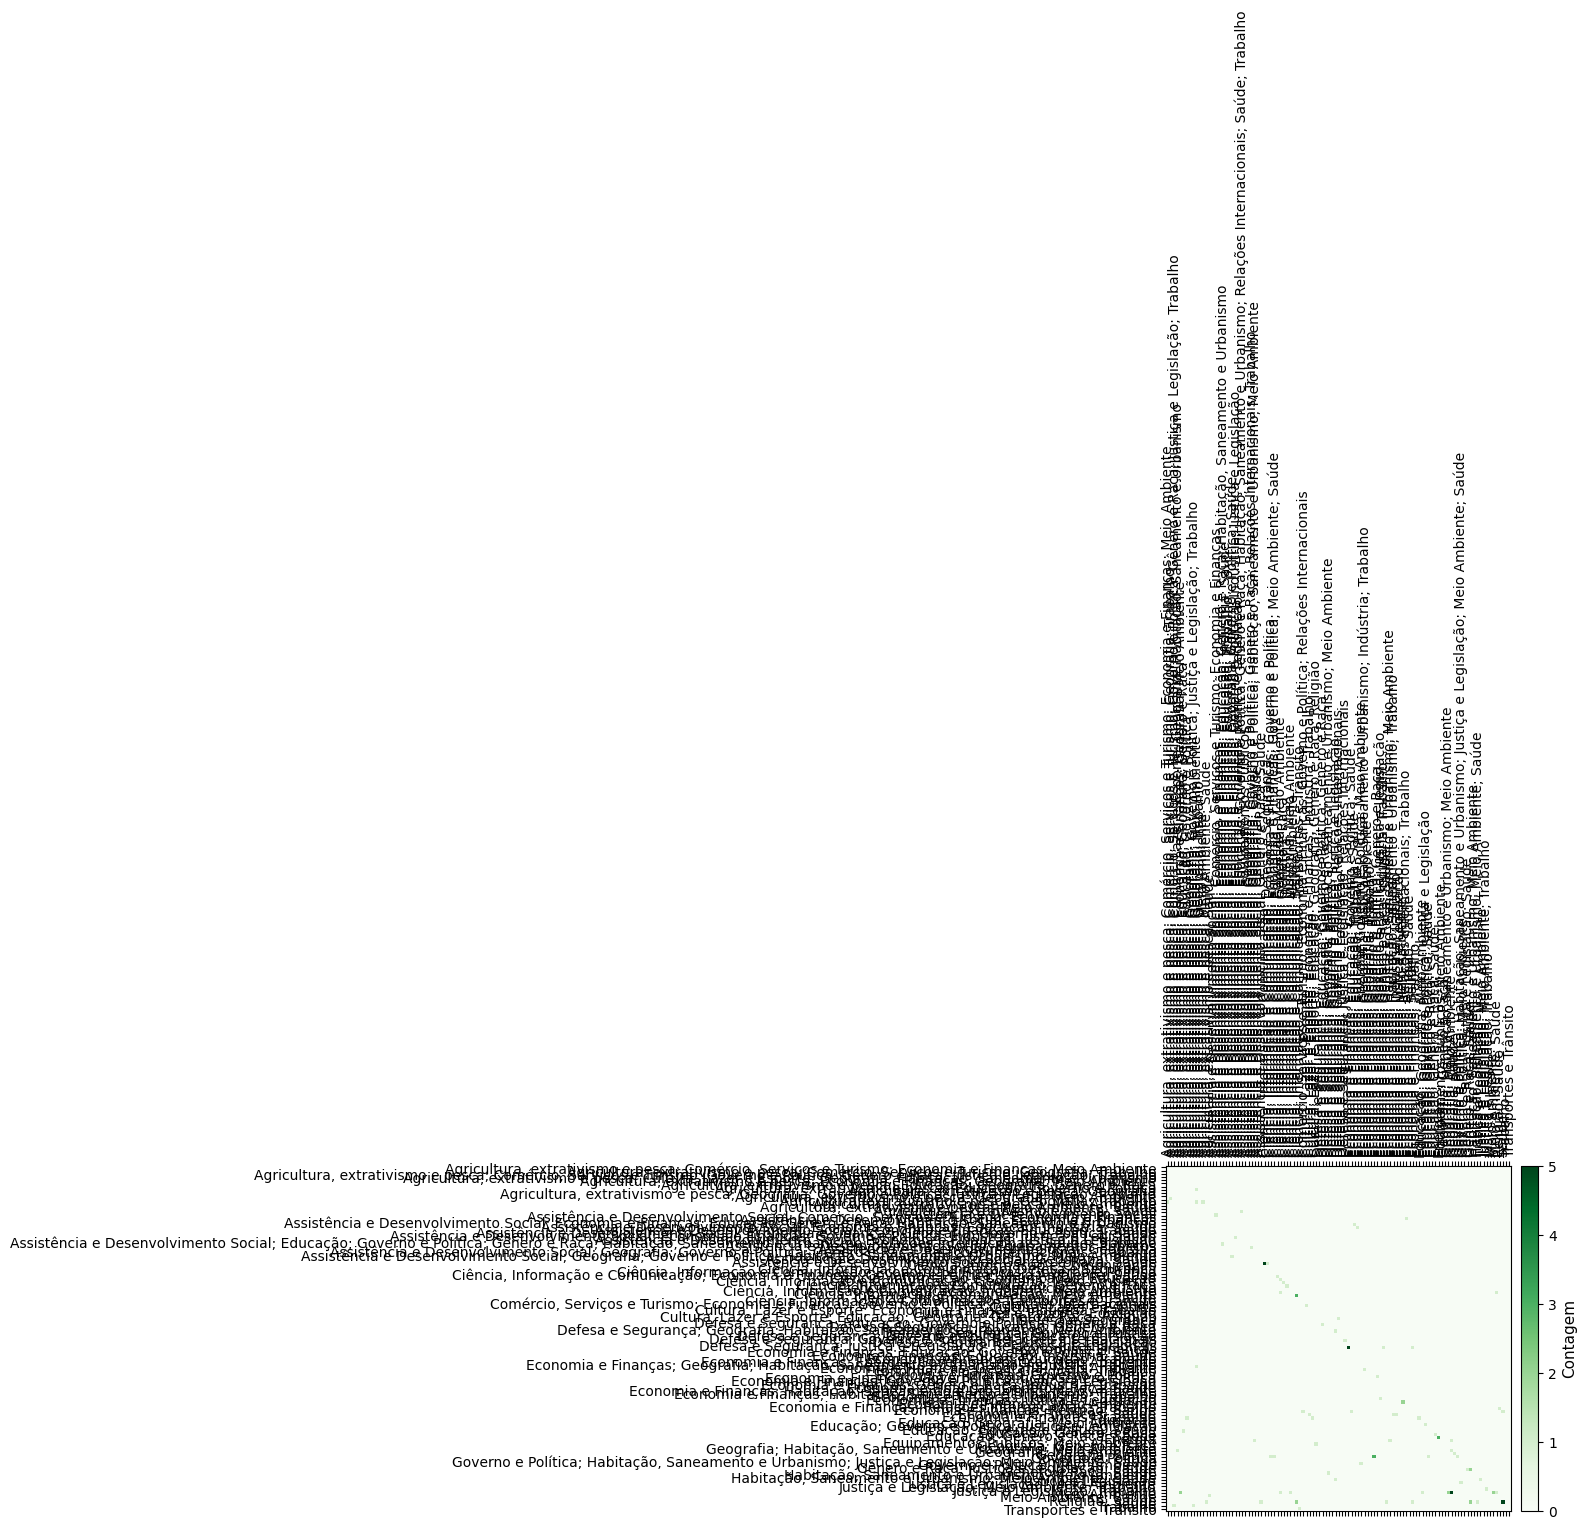

In [84]:
xp.matrix_show(topics_cm, 'Greens', 'Contagem')

### Resto do código anterior

In [56]:
# Save results to CSV:
#results_df = du.build_results_csv(data_file, detector.jsonl_in, detector.jsonl_out, du.in2out_name(data_file, out_suffix='gpt-pred', file_extension='.csv'))

# Preparando os dados

In [66]:
import pandas as pd
import json

import xavy.explore as xe
import xavy.dataframes as xd

In [9]:
# Carregando dados brutos:
ufpe_df = pd.read_csv('../dados/dspaces/tccs-dissertacoes-teses-2024-ufpe_gpt-public-data_annot_v02.csv')
ufam_df = pd.read_csv('/home/hxavier/temp/ufam.csv') 
ufcg_df = pd.read_csv('/home/hxavier/temp/ufcg.csv')

Os dados na pasta `temp` acima foram obtidos das referidas abas da [planilha no Google Sheets](https://docs.google.com/spreadsheets/d/1bD2Y8PiXE8-orH-wpki2K0UkaKPOxKK3DfACziZAfMM), através da exportação para CSV.

In [72]:
# Selecionando casos que tinham uso de dados públicos:
sel_ufpe_df = ufpe_df.loc[ufpe_df['y'] == 1].copy()
sel_ufpe_df['instituicao'] = 'UFPE'
sel_ufam_df = ufam_df.loc[ufam_df['usou_dados_publicos'] == 1].copy()
sel_ufam_df.rename({'uri_link': 'uri'}, axis=1, inplace=True)
sel_ufam_df['uri'] = sel_ufam_df['uri'].str.replace('http://', 'https://')
sel_ufam_df['instituicao'] = 'UFAM'
sel_ufcg_df = ufcg_df.loc[ufcg_df['usou_dados_publicos'] == 1].copy()
sel_ufcg_df['instituicao'] = 'UFCG'

# Seleciona colunas relevantes e junta as bases:
sel_cols = ['uri', 'titulo', 'resumo', 'palavras_chave', 'instituicao']
sel_df = pd.concat([sel_ufpe_df[sel_cols], sel_ufam_df[sel_cols], sel_ufcg_df[sel_cols]], ignore_index=True)

In [73]:
# Carrega dados catalogados 
with open('../dados/backups/usecases_bkp_2026-03-24.json', 'r') as f:
    cordata = json.load(f)
data_df = pd.DataFrame(cordata['data'])

In [74]:
# Junta os dados:
joined_df = sel_df.join(data_df.set_index('url'), how='left', on='uri')

Os casos faltantes são (quase) todos da UFPE e mencionam PubMed: eles são os casos adicionados após a modificação do prompt para pegar o uso de bases bibliográficas.

In [81]:
# Verificando os casos faltantes:
missing_hash_df = joined_df.loc[joined_df['hash_id'].isnull()]
xd.print_string_series(missing_hash_df.set_index('instituicao')['titulo'])

print(missing_hash_df['resumo'].str.contains('pubmed', case=False))

UFPE: Contribuição das cirurgias pré-protéticas para adaptação das Próteses totais
UFPE: Fisioterapia no tratamento de pacientes com hanseníase : uma revisão de escopo
UFPE: O papel da cianidina-3-O-glicosídeo, uma antocianina, na prevenção e tratamento das doenças do sistema nervoso : uma revisão integrativa
UFPE: O efeito da flexão nórdica sobre a força dos flexores de joelhos e fatores de risco de lesões em atletas de futebol: uma revisão de literatura.
UFPE: Maloclusões em crianças e adolescentes autistas
UFPE: Panorama atual sobre o desenvolvimento de vacinas para a Tricomoníase: uma revisão integrativa
UFPE: Fatores relacionados à alimentação saudável dos 6 meses aos dois anos de  vida da criança: revisão de escopo
UFPE: Influência do ciclo menstrual no desempenho físico de atletas femininas: Um estudo de revisão
UFPE: Genômica estrutural, comparativa e funcional de genes codificadores de helicases expressos em pinhão-manso (Jatropha curcas L.) sob estresse salino
UFPE: Ocorrênci

In [90]:
# Junta os dados:
joined_df = sel_df.join(data_df.set_index('url'), how='inner', on='uri')
# Seleciona os que interessam
test_cols = ['hash_id', 'uri', 'titulo', 'resumo', 'palavras_chave', 'topics', 'type', 'geo_level']
test_df = joined_df.loc[~joined_df['hash_id'].isnull(), test_cols]

In [92]:
# Export test data:
#test_df.to_csv('../dados/dspaces/testing/metadata-llm-collect_test-sample_v01.csv', index=False)